Import relevant libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bokeh.palettes import Viridis8

**Problem 1b**

In [2]:
# Set calibration parameters
sigma = 0.036
mu = 0.018
gamma = 10
beta = 0.99

# Simulate 100,000 shocks of log consumption growth
n_sim = 100000
rng = np.random.default_rng(10)
eps = rng.normal(size=n_sim)

# Years
years = np.arange(1, n_sim+1)

# Risk-free rate series (constant, does not depend on the shocks)
rf = -np.log(beta) + gamma*mu - 0.5*(gamma**2)*(sigma**2)             
rf_series = np.full(n_sim, rf)

# Log consumption growth
delta_c = mu + sigma*eps

# Log stochastic discount factor      
m = np.log(beta) - gamma*(mu + sigma*eps)

# Log equity return
rd = -np.log(beta) + gamma*mu - 0.5*((1-gamma)**2)*(sigma**2) + sigma*eps

# Store all the simulation results in a pandas data frame
sim_df = pd.DataFrame(data={
    'year': years,
    'rf': rf_series,
    'delta_c': delta_c,
    'm': m,
    'rd': rd
})
sim_df.head()

,year,rf,delta_c,m,rd
0,1,0.12525,-0.021720,0.207152,0.097842
1,2,0.12525,-0.008101,0.070959,0.111461
2,3,0.12525,-0.010145,0.091400,0.109417
3,4,0.12525,0.027611,-0.286162,0.147173
4,5,0.12525,0.009051,-0.100561,0.128613


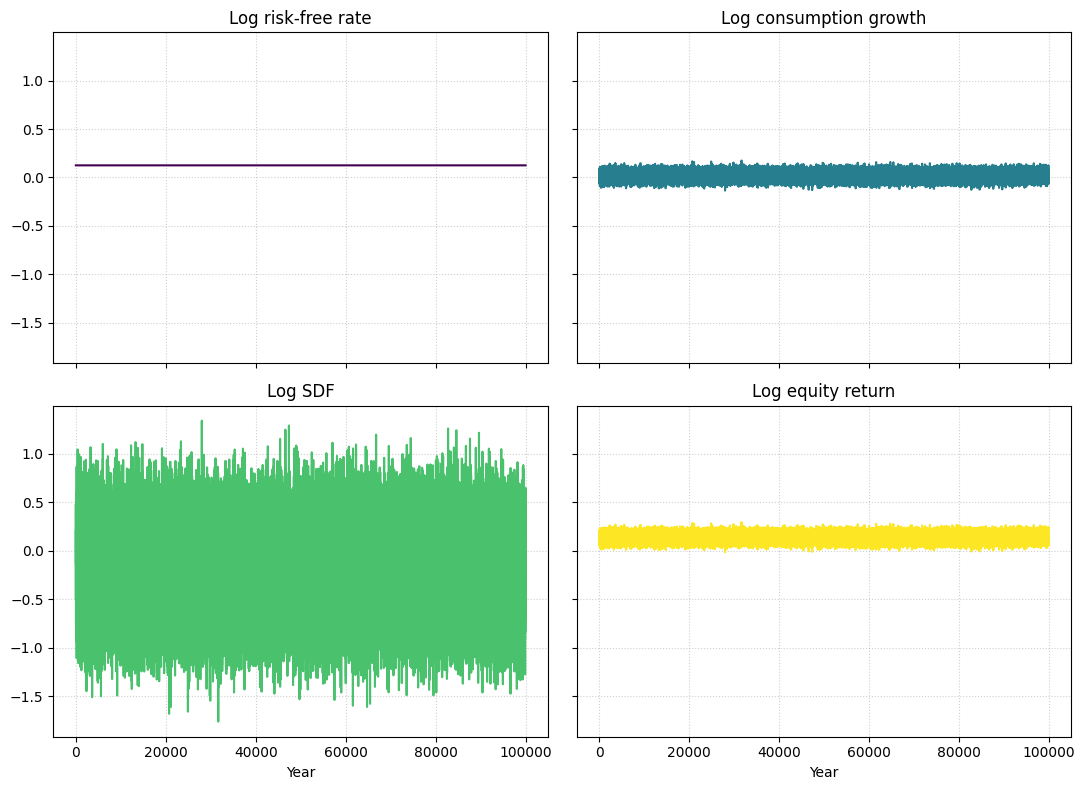

In [3]:
# Plot simulation results

# Common y-limits across all subplots
ymin = min(rf.min(), delta_c.min(), m.min(), rd.min())
ymax = max(rf.max(), delta_c.max(), m.max(), rd.max())
pad = 0.05 * (ymax - ymin)
ylims = (ymin - pad, ymax + pad)

# --- Figure with 4 subplots sharing y-axis ---
fig, axs = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)

axs = axs.ravel()
axs[0].plot(years, rf_series, color=Viridis8[0])
axs[0].set_title("Log risk-free rate")

axs[1].plot(years, delta_c, color=Viridis8[3])
axs[1].set_title("Log consumption growth")

axs[2].plot(years, m, color=Viridis8[5])
axs[2].set_title("Log SDF")

axs[3].plot(years, rd, color=Viridis8[7])
axs[3].set_title("Log equity return")

for ax in axs:
    ax.set_ylim(*ylims)
    ax.grid(True, linestyle=':', alpha=0.6)

# Labels
axs[2].set_xlabel("Year"); axs[3].set_xlabel("Year")

fig.tight_layout()
plt.show()


In [4]:
# Compute the mean, standard deviation, and first autocorrelation of each series
col_labels = {
    'rf': 'Risk-free rate', 
    'delta_c': 'Log consumption growth', 
    'm': 'Log SDF', 
    'rd': 'Log equity return'
}

for col in ['rf', 'delta_c', 'm', 'rd']:
    print(col_labels[col])
    print(f'Mean: {np.mean(sim_df[col]):.4f}')
    print(f'Standard deviation: {np.std(sim_df[col], ddof=1):.4f}')
    if col != 'rf': print(f'First autocorrelation: {sim_df[col].autocorr(lag=1):.4f}')
    print('-'*50)

Risk-free rate
Mean: 0.1253
Standard deviation: 0.0000
--------------------------------------------------
Log consumption growth
Mean: 0.0180
Standard deviation: 0.0361
First autocorrelation: 0.0016
--------------------------------------------------
Log SDF
Mean: -0.1898
Standard deviation: 0.3612
First autocorrelation: 0.0016
--------------------------------------------------
Log equity return
Mean: 0.1375
Standard deviation: 0.0361
First autocorrelation: 0.0016
--------------------------------------------------


In [5]:
# Compute the correlation between log consumption growth and the equity return
print(f'Correlation between log consumption growth and the equity return: {np.corrcoef(sim_df['delta_c'], sim_df['rd'])[0,1]:.4f}')

Correlation between log consumption growth and the equity return: 1.0000


**Problem 2b**

In [6]:
# Set calibration parameters
rho = 0.4
sigma = np.sqrt(0.036**2 * (1-0.4**2))
mu = 0.018
gamma = 10
beta = 0.99

In [7]:
# The log equity return depends on the parameters rho_cs and kappa,
# Which in turn depend on the mean d-p implied by the model.
# For this reason, I use fixed-point iteration to find these parameters.

def rho_cs_kappa(xbar):
    rho_cs = 1.0 / (1.0 + np.exp(xbar))
    kappa  = -np.log(rho_cs) - (1 - rho_cs) * np.log(1 / rho_cs - 1)
    return rho_cs, kappa

def policy_coeffs(xbar):
    rho_cs, kappa = rho_cs_kappa(xbar)
    a1 = rho * (gamma - 1) / (1 - rho * rho_cs)
    a0 = -( np.log(beta) + kappa + (1 - a1 * rho_cs - gamma) * (1 - rho) * mu + 0.5 * (1 - a1 * rho_cs - gamma)**2 * sigma**2 ) / (1 - rho_cs)
    return a0, a1, rho_cs, kappa

def find_xbar(x0=np.log(5.0), tol=1e-12, maxit=100000):
    x = x0
    for _ in range(maxit):
        a0, a1, rho_cs, kappa = policy_coeffs(x)
        x_new = a0 + a1 * mu                      
        if abs(x_new - x) < tol:
            return {"xbar": x_new, "a0": a0, "a1": a1, "rho_cs": rho_cs, "kappa": kappa, "iters": _+1}
        x = x_new
    raise RuntimeError("Fixed-point iteration did not converge.")

sol = find_xbar()
print(sol)

{'xbar': np.float64(-2.812293804441001), 'a0': np.float64(-2.9163625422373762), 'a1': np.float64(5.781596544243069), 'rho_cs': np.float64(0.9433365539901594), 'kappa': np.float64(0.21768642104668107), 'iters': 19}


In [8]:
# Now, I can perform the actual simulation.

# Simulate 100,000 shocks of log consumption growth
n_sim = 100000
rng = np.random.default_rng(10)
eps = rng.normal(size=n_sim)

# Years
years = np.arange(1, n_sim+1)

# Log consumption growth (AR(1) process)
delta_c = np.empty(n_sim+1)
delta_c[0] = mu
for year in years:
    delta_c[year] = (1-rho)*mu + rho*delta_c[year-1] + sigma * eps[year-1]


# Risk-free rate series (known at the beginning of each period)
rf = -np.log(beta) + gamma*mu - 0.5*(gamma**2)*(sigma**2) + gamma * rho * (delta_c[:-1]-mu)         

# Log stochastic discount factor      
m = np.log(beta) - gamma*delta_c[1:]

# Log equity return
rho_cs = sol['rho_cs']
rd = -np.log(beta) + gamma*(1-rho)*mu - 0.5*((1-gamma)/(1-rho*rho_cs))**2*(sigma**2) + rho*gamma*delta_c[:-1] + ((1-gamma*rho*rho_cs)/(1-rho*rho_cs))*sigma*eps

# Log equity premium
rd_rf = 0.5*(gamma**2 - ((1-gamma)/(1-rho*rho_cs))**2)*sigma**2 + ((1-gamma*rho*rho_cs)/(1-rho*rho_cs))*sigma*eps

# Store all the simulation results in a pandas data frame
sim_df = pd.DataFrame(data={
    'year': years,
    'rf': rf,
    'delta_c': delta_c[1:],
    'm': m,
    'rd': rd,
    'rd_rf': rd_rf
})
sim_df.head()

,year,rf,delta_c,m,rd,rd_rf
0,1,0.135618,-0.018404,0.173991,0.238476,0.102858
1,2,-0.009998,-0.020484,0.194785,0.037263,0.047262
2,3,-0.018316,-0.023189,0.221837,0.037290,0.055606
3,4,-0.029137,0.010333,-0.113383,-0.127657,-0.098520
4,5,0.104951,0.006731,-0.077365,0.082196,-0.022755


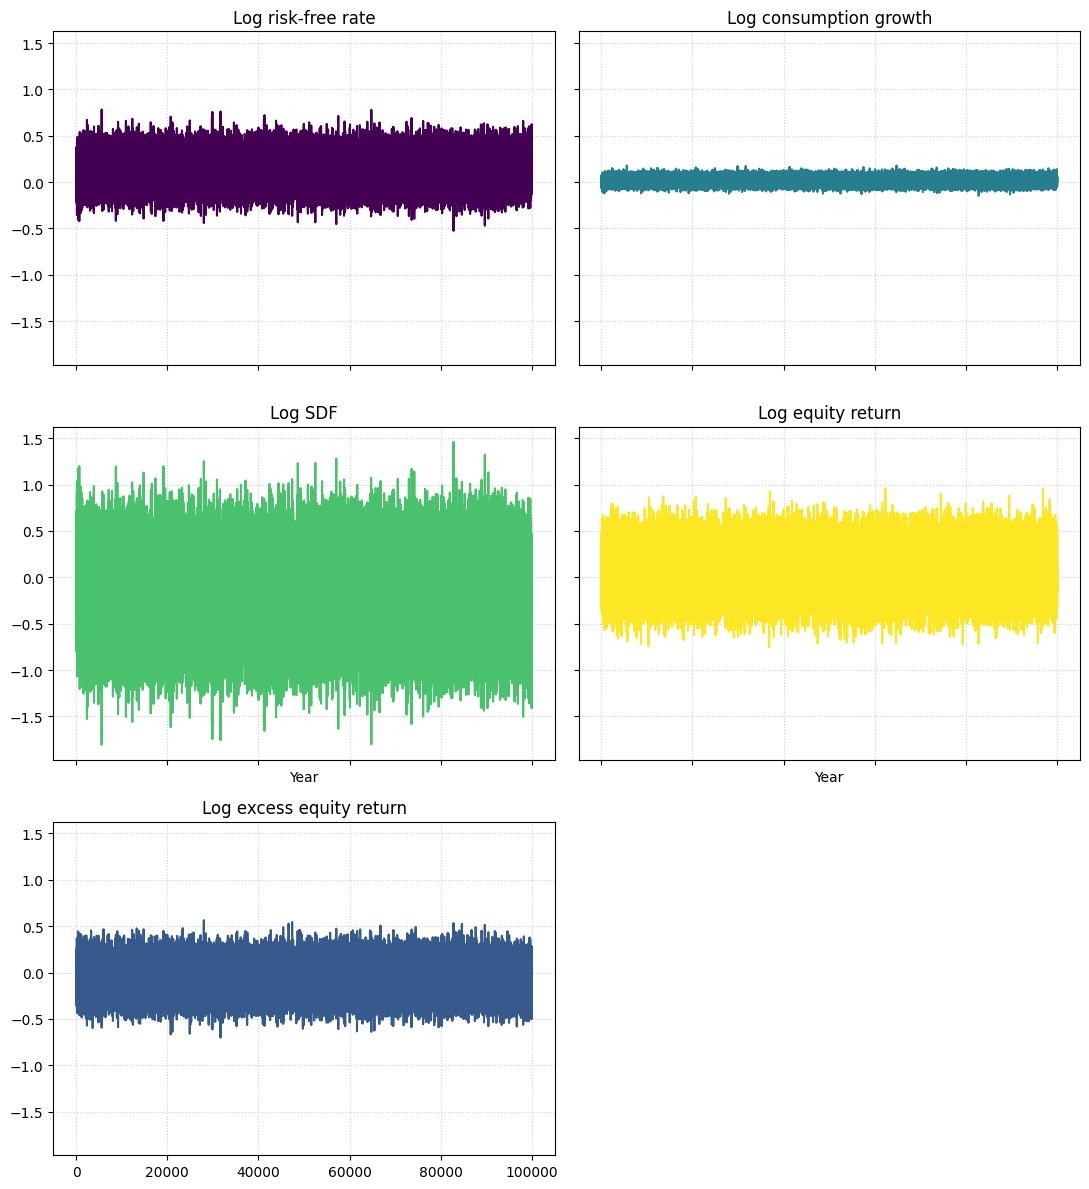

In [9]:
# Plot simulation results

# Common y-limits across all subplots
ymin = min(rf.min(), delta_c.min(), m.min(), rd.min(), rd_rf.min())
ymax = max(rf.max(), delta_c.max(), m.max(), rd.max(), rd_rf.max())
pad = 0.05 * (ymax - ymin)
ylims = (ymin - pad, ymax + pad)

# --- Figure with 4 subplots sharing y-axis ---
fig, axs = plt.subplots(3, 2, figsize=(11, 12), sharex=True, sharey=True)

axs = axs.ravel()
axs[0].plot(years, rf, color=Viridis8[0])
axs[0].set_title("Log risk-free rate")

axs[1].plot(years, delta_c[1:], color=Viridis8[3])
axs[1].set_title("Log consumption growth")

axs[2].plot(years, m, color=Viridis8[5])
axs[2].set_title("Log SDF")

axs[3].plot(years, rd, color=Viridis8[7])
axs[3].set_title("Log equity return")

axs[4].plot(years, rd_rf, color=Viridis8[2])
axs[4].set_title("Log excess equity return")

fig.delaxes(axs[5])

for ax in axs:
    ax.set_ylim(*ylims)
    ax.grid(True, linestyle=':', alpha=0.6)

# Labels
axs[2].set_xlabel("Year"); axs[3].set_xlabel("Year")

fig.tight_layout()
plt.show()


In [10]:
# Compute the mean, standard deviation, and first autocorrelation of each series
col_labels = {
    'rf': 'Risk-free rate', 
    'delta_c': 'Log consumption growth', 
    'm': 'Log SDF', 
    'rd': 'Log equity return',
    'rd_rf': 'Log excess equity return'
}

for col in ['rf', 'delta_c', 'm', 'rd', 'rd_rf']:
    print(col_labels[col])
    print(f'Mean: {np.mean(sim_df[col]):.4f}')
    print(f'Standard deviation: {np.std(sim_df[col], ddof=1):.4f}')
    print(f'First autocorrelation: {sim_df[col].autocorr(lag=1):.4f}')
    print('-'*50)

Risk-free rate
Mean: 0.1355
Standard deviation: 0.1444
First autocorrelation: 0.3990
--------------------------------------------------
Log consumption growth
Mean: 0.0180
Standard deviation: 0.0361
First autocorrelation: 0.3990
--------------------------------------------------
Log SDF
Mean: -0.1897
Standard deviation: 0.3611
First autocorrelation: 0.3990
--------------------------------------------------
Log equity return
Mean: 0.0763
Standard deviation: 0.2065
First autocorrelation: -0.2584
--------------------------------------------------
Log excess equity return
Mean: -0.0592
Standard deviation: 0.1475
First autocorrelation: 0.0016
--------------------------------------------------


In [11]:
# Compute the correlation between log consumption growth and the equity return
print(f'Correlation between log consumption growth and the equity return: {np.corrcoef(sim_df['delta_c'], sim_df['rd'])[0,1]:.4f}')

Correlation between log consumption growth and the equity return: -0.3754


**Problem 2c**

In [14]:
# Define function that computes the coefficients A_n and B_n associated with each bond maturity
def bond_AB(n_max, rho, mu, gamma, beta, sigma):
    A = np.zeros(n_max + 1)  
    B = np.zeros(n_max + 1)  
    for n in range(n_max):
        A[n+1] = (-np.log(beta) + A[n] + (gamma + B[n]) * (1 - rho) * mu - 0.5 * (gamma + B[n])**2 * sigma**2)
        B[n+1] = rho * (gamma + B[n])
    return A[1:], B[1:] 

# compute A_n, B_n for n_max=5
A, B = bond_AB(5, rho, mu, gamma, beta, sigma)

# Use the delta_c simulated series above to simulate bond yields
yields_sim = pd.DataFrame({f"y{i}": (A[i-1] + B[i-1]*delta_c[1:])/i for i in range(1, 6)})
yields_sim.head()


,y1,y2,y3,y4,y5
0,-0.009998,0.007559,0.016468,0.021644,0.024956
1,-0.018316,0.001737,0.012143,0.018268,0.022212
2,-0.029137,-0.005837,0.006516,0.013874,0.018642
3,0.104951,0.088024,0.076242,0.068314,0.062880
4,0.090544,0.077939,0.068750,0.062465,0.058127


In [17]:
# Compute the mean, standard deviation, and first autocorrelation of each series
for col in yields_sim.columns:
    print(col)
    print(f'Mean: {np.mean(yields_sim[col]):.4f}')
    print(f'Standard deviation: {np.std(yields_sim[col], ddof=1):.4f}')
    print(f'First autocorrelation: {yields_sim[col].autocorr(lag=1):.4f}')
    print('-'*50)

y1
Mean: 0.1355
Standard deviation: 0.1444
First autocorrelation: 0.3990
--------------------------------------------------
y2
Mean: 0.1094
Standard deviation: 0.1011
First autocorrelation: 0.3990
--------------------------------------------------
y3
Mean: 0.0921
Standard deviation: 0.0751
First autocorrelation: 0.3990
--------------------------------------------------
y4
Mean: 0.0807
Standard deviation: 0.0586
First autocorrelation: 0.3990
--------------------------------------------------
y5
Mean: 0.0730
Standard deviation: 0.0476
First autocorrelation: 0.3990
--------------------------------------------------
